# Config

In [2]:
import numpy as np

# Constants for the maze configuration
MAZE_DIMENSION = 20
START_POSITION = (0, 0)
TARGET_POSITION = (MAZE_DIMENSION - 1, MAZE_DIMENSION - 1)

def initialize_maze_layout(size):
    """ Define the hardcoded maze grid and return it as a NumPy array. """
    maze_layout = [
        [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
        [0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0],
        [0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0],
        [0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0],
        [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0],
        [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0], 
        [1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0], 
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0], 
        [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
        [0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0],
        [0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0],
        [0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0],
        [0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0],
        [0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0],
        [0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0],
        [0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0],
        [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0]
    ]
    return np.array(maze_layout)

# BFS

In [3]:
from collections import deque

def find_shortest_path_bfs(maze_grid, start_node, target_node):
    """ Search for the shortest path using the Breadth-First Search algorithm. """
    total_rows, total_cols = maze_grid.shape
    movement_directions = [(-1, 0), (0, 1), (1, 0), (0, -1)] # Up, Right, Down, Left
    
    exploration_queue = deque([(start_node, [start_node])])
    visited_cells = {start_node}
    
    while exploration_queue:
        (current_row, current_col), current_path = exploration_queue.popleft()
        
        # Stop and return if we reached the target
        if (current_row, current_col) == target_node:
            return current_path
            
        # Explore neighboring cells
        for row_step, col_step in movement_directions:
            next_row, next_col = current_row + row_step, current_col + col_step
            
            is_within_bounds = (0 <= next_row < total_rows) and (0 <= next_col < total_cols)
            
            if is_within_bounds and maze_grid[next_row, next_col] == 0 and (next_row, next_col) not in visited_cells:
                visited_cells.add((next_row, next_col))
                exploration_queue.append(((next_row, next_col), current_path + [(next_row, next_col)]))
                
    return None

# Visualization

In [4]:
import matplotlib.pyplot as plt
import numpy as np

def display_single_path(maze_grid, path_coordinates=None, window_title="Maze Visualization"):
    """ Plot the maze and a single path. Legend is moved away from the drawing. """
    plt.figure(figsize=(8, 8))
    plt.imshow(maze_grid, cmap='binary')
    
    plt.xticks(np.arange(MAZE_DIMENSION))
    plt.yticks(np.arange(MAZE_DIMENSION))
    plt.grid(True, linestyle=':', alpha=0.6)

    # Plot start and goal points
    plt.plot(START_POSITION[1], START_POSITION[0], 'go', markersize=10, label='Start Node')
    plt.plot(TARGET_POSITION[1], TARGET_POSITION[0], 'ro', markersize=10, label='Target Node')

    if path_coordinates:
        path_y, path_x = zip(*path_coordinates)
        plt.plot(path_x, path_y, color='blue', linewidth=3, label='BFS Path')
        plt.title(f"{window_title} - Path Length: {len(path_coordinates)}")
    else:
        plt.title(window_title)
        
    # Place the legend completely outside the maze boundaries
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12, framealpha=1.0)
    plt.tight_layout() # Ensure nothing gets cut off
    plt.show()

def display_algorithm_comparison(maze_grid, path_from_bfs, path_from_ga):
    """ Plot both paths for comparison, keeping the legend out of the maze area. """
    plt.figure(figsize=(10, 10))
    plt.imshow(maze_grid, cmap='binary')
    plt.grid(True, linestyle=':', alpha=0.6)
    
    # Plot start and goal points
    plt.plot(START_POSITION[1], START_POSITION[0], 'go', markersize=10, label='Start Node')
    plt.plot(TARGET_POSITION[1], TARGET_POSITION[0], 'ro', markersize=10, label='Target Node')
    
    if path_from_bfs:
        bfs_y, bfs_x = zip(*path_from_bfs)
        plt.plot(bfs_x, bfs_y, color='blue', linewidth=5, alpha=0.6, label='BFS Path')
        
    if path_from_ga:
        ga_y, ga_x = zip(*path_from_ga)
        plt.plot(ga_x, ga_y, color='red', linewidth=2, linestyle='--', label='GA Path')
        
    plt.title("Path Comparison: BFS vs GA")
    
    # Place the legend completely outside the maze boundaries
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12, framealpha=1.0)
    plt.tight_layout() # Ensure nothing gets cut off
    plt.show()

# GA

In [5]:
import random

def execute_chromosome_moves(maze_grid, start_node, target_node, movement_genes):
    """ Simulate the path a chromosome takes inside the maze. """
    current_row, current_col = start_node
    traveled_path = [(current_row, current_col)]
    directions = [(-1, 0), (0, 1), (1, 0), (0, -1)]
    total_rows, total_cols = maze_grid.shape
    
    for gene in movement_genes:
        row_step, col_step = directions[gene]
        next_row, next_col = current_row + row_step, current_col + col_step
        
        # Move only if the next cell is inside the maze and is not a wall (0)
        is_within_bounds = (0 <= next_row < total_rows) and (0 <= next_col < total_cols)
        if is_within_bounds and maze_grid[next_row, next_col] == 0:
            current_row, current_col = next_row, next_col
            traveled_path.append((current_row, current_col))
            
        # Stop early if the goal is reached
        if (current_row, current_col) == target_node:
            break
            
    return current_row, current_col, traveled_path

def evaluate_chromosome_fitness(maze_grid, start_node, target_node, movement_genes):
    """ Calculate how good a chromosome is based on its distance to the target. """
    final_row, final_col, path_taken = execute_chromosome_moves(maze_grid, start_node, target_node, movement_genes)
    
    # Manhattan distance to the goal
    distance_to_target = abs(target_node[0] - final_row) + abs(target_node[1] - final_col)
    
    fitness_score = 1.0 / (distance_to_target + 1)
    
    # Massive bonus for reaching the goal, plus a small bonus for shorter paths
    if distance_to_target == 0:
        fitness_score += 1000 + (1000.0 / len(path_taken))
        
    return fitness_score

def random_mutation(chromosome, lower_bound=0, upper_bound=3, mutation_rate=0.05):
    """ Pick a gene randomly and change it to a random value within allowed limits. """
    for i in range(len(chromosome)):
        if random.random() < mutation_rate:
            chromosome[i] = random.randint(lower_bound, upper_bound)
    return chromosome

def inorder_mutation(chromosome, mutation_rate=0.05):
    """ Select two positions and swap their values (Swap Mutation). """
    if random.random() < mutation_rate:
        i = random.randint(0, len(chromosome) - 1)
        j = random.randint(0, len(chromosome) - 1)
        chromosome[i], chromosome[j] = chromosome[j], chromosome[i]
    return chromosome

def find_path_genetic_algorithm(maze_grid, start_node, target_node, population_size=150, max_generations=300, chromosome_len=100):
    """ Run a Genetic Algorithm to evolve a solution to the maze. """
    current_population = [[random.randint(0, 3) for _ in range(chromosome_len)] for _ in range(population_size)]
    
    best_discovered_path = None
    highest_fitness_score = -1
    best_fitness_history = [] # Added for Convergence Termination
    
    for generation in range(max_generations):
        evaluated_population = []
        
        # Evaluate fitness for all chromosomes
        for individual_chromosome in current_population:
            fitness = evaluate_chromosome_fitness(maze_grid, start_node, target_node, individual_chromosome)
            evaluated_population.append((fitness, individual_chromosome))
            
            # Keep track of the best path found across all generations
            if fitness > highest_fitness_score:
                highest_fitness_score = fitness
                _, _, best_discovered_path = execute_chromosome_moves(maze_grid, start_node, target_node, individual_chromosome)
                
        # Sort so the fittest chromosomes are at the beginning
        evaluated_population.sort(key=lambda item: item[0], reverse=True)
        
        # Track history for convergence
        best_fitness_history.append(highest_fitness_score)
        # --- TERMINATION PHASE ---
        # 1. Target Found
        if highest_fitness_score > 500:
            print(f"-> Genetic Algorithm reached the target at generation {generation}!")
            break
            
        # 2. Convergence (Stop if no improvement for 20 consecutive generations)
        if len(best_fitness_history) > 20 and len(set(best_fitness_history[-20:])) == 1:
            print(f"-> [TERMINATION] Convergence reached at Generation {generation}. Fitness stopped improving.")
            break
            
        # Elitism: Automatically carry over the top 2 performers
        next_generation = [evaluated_population[0][1], evaluated_population[1][1]]
        
        # Breed the rest of the new generation using the top 50%
        while len(next_generation) < population_size:
            parent_one = random.choice(evaluated_population[:population_size//2])[1]
            parent_two = random.choice(evaluated_population[:population_size//2])[1]
            
            # Single-point crossover
            crossover_point = random.randint(0, chromosome_len - 1)
            offspring = parent_one[:crossover_point] + parent_two[crossover_point:]
            
            # Mutation: Using Random Mutation
            offspring = random_mutation(offspring, lower_bound=0, upper_bound=3, mutation_rate=0.05)
                
            next_generation.append(offspring)
            
        current_population = next_generation
        
    return best_discovered_path

# Main

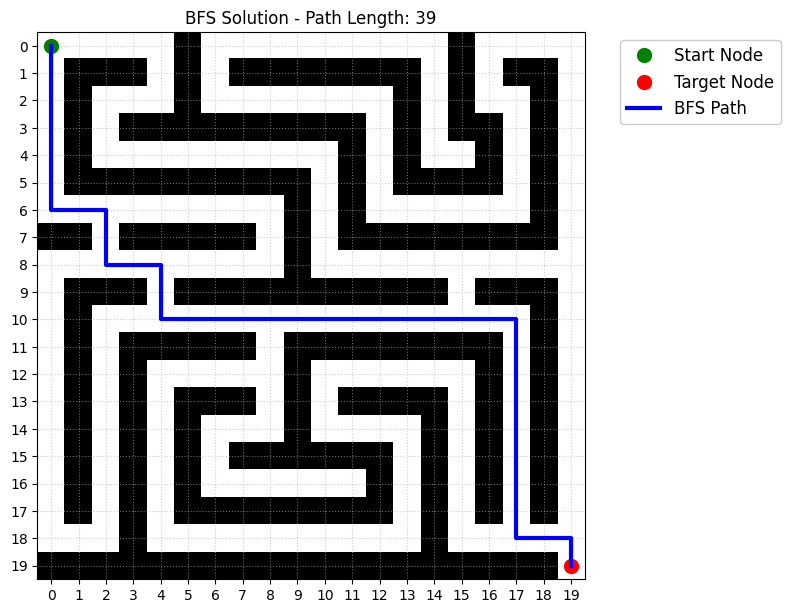

-> Genetic Algorithm reached the target at generation 3!

📍 MAZE DETAILS & RESULTS
Start Node : (0, 0)
Target Node: (19, 19)
--------------------------------------------------
🔵 BFS PATH (Steps: 39):
[(0, 0), (1, 0), (2, 0), (3, 0), (4, 0), (5, 0), (6, 0), (6, 1), (6, 2), (7, 2), (8, 2), (8, 3), (8, 4), (9, 4), (10, 4), (10, 5), (10, 6), (10, 7), (10, 8), (10, 9), (10, 10), (10, 11), (10, 12), (10, 13), (10, 14), (10, 15), (10, 16), (10, 17), (11, 17), (12, 17), (13, 17), (14, 17), (15, 17), (16, 17), (17, 17), (18, 17), (18, 18), (18, 19), (19, 19)]
--------------------------------------------------
🔴 GA PATH (Steps: 93):
[(0, 0), (0, 1), (0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (1, 4), (2, 4), (1, 4), (2, 4), (2, 3), (2, 4), (1, 4), (0, 4), (0, 3), (0, 2), (0, 3), (0, 4), (0, 3), (0, 4), (1, 4), (2, 4), (1, 4), (0, 4), (0, 3), (0, 4), (1, 4), (2, 4), (1, 4), (2, 4), (1, 4), (2, 4), (2, 3), (2, 2), (2, 3), (2, 4), (2, 3), (2, 4), (2, 3), (2, 2), (3, 2), (4, 2), (4, 3), (4, 4), (4, 5), 

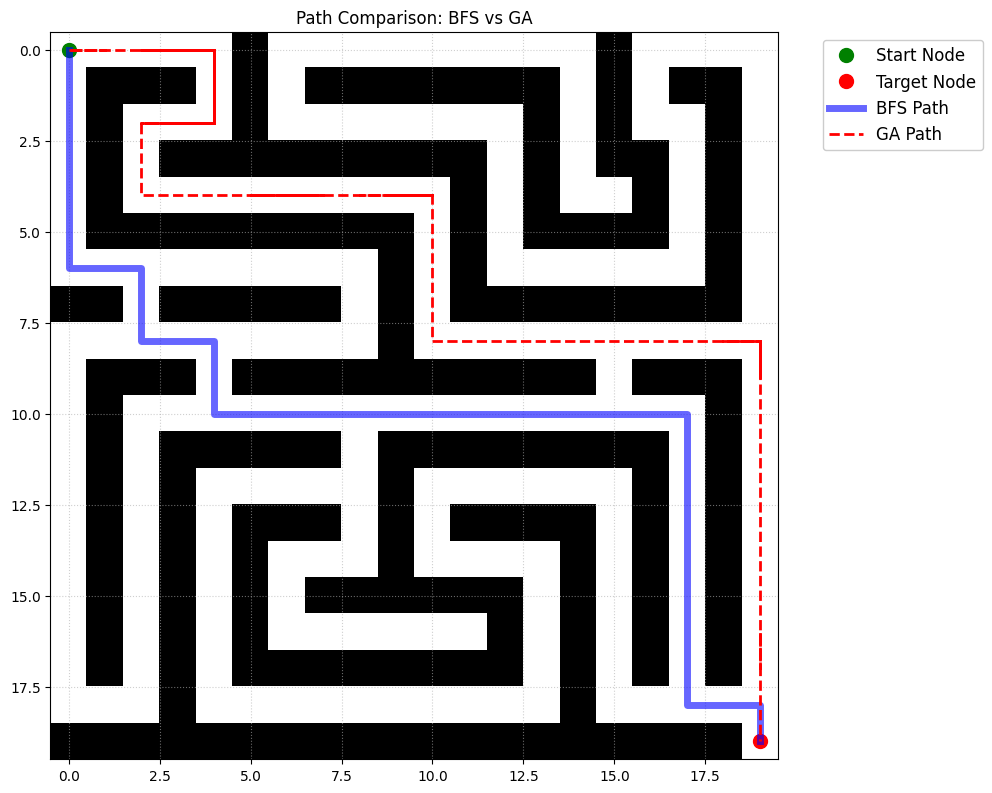

In [6]:

if __name__ == "__main__":
    # 1. Initialize Maze
    maze_grid = initialize_maze_layout(MAZE_DIMENSION)

    # 2. Run BFS
    bfs_solution_path = find_shortest_path_bfs(maze_grid, START_POSITION, TARGET_POSITION)
    display_single_path(maze_grid, bfs_solution_path, window_title="BFS Solution")

    # 3. Run Genetic Algorithm
    ga_solution_path = find_path_genetic_algorithm(maze_grid, START_POSITION, TARGET_POSITION, population_size=600, max_generations=1000, chromosome_len=200)

    # 4. Display text summaries in the console to keep plots clean
    print("\n" + "="*50)
    print("📍 MAZE DETAILS & RESULTS")
    print("="*50)
    print(f"Start Node : {START_POSITION}")
    print(f"Target Node: {TARGET_POSITION}")
    print("-" * 50)
    
    if bfs_solution_path:
        print(f"🔵 BFS PATH (Steps: {len(bfs_solution_path)}):")
        print(bfs_solution_path)
    else:
        print("🔵 BFS PATH: No valid path found.")
        
    print("-" * 50)
    
    if ga_solution_path:
        print(f"🔴 GA PATH (Steps: {len(ga_solution_path)}):")
        print(ga_solution_path)
    else:
        print("🔴 GA PATH: Algorithm did not reach the target.")
    print("="*50 + "\n")

    # 5. Display comparison plot
    display_algorithm_comparison(maze_grid, bfs_solution_path, ga_solution_path)